In [19]:
# Importing Pytorch library
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Importing transformers library for working with models from HuggingFace
from transformers import ElectraTokenizer, AutoModel

# Importing re library for regular expressions
import re

# Importing library for calculating F1 score
from sklearn.metrics import f1_score

# Importing library for easing training and visualizing its progress
from tqdm import tqdm, trange
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

IMPORTS ^

In [ ]:
# Loading training data
with open("train_data.utf8", "r", encoding="utf-8") as f:
    text_data = f.read()

# Newline character is replaced with a space
text_data = text_data.replace("\n", " ")

# Remove all non-standard characters
text_data_clean = re.sub(r'[^a-zA-Z0-9.,!?áčďéěíňóřšťúůýžÁČĎÉĚÍŇÓŘŠŤÚŮÝŽ ]', '', text_data)

# Remove duplicate spaces
text_data_clean = re.sub(r'\s+', ' ', text_data_clean).strip()


LOADING TRAINING DATA ^ 

In [21]:
class CapitalizationModel(nn.Module):
    def __init__(self, name):
        super(CapitalizationModel, self).__init__()
        self.electra_model = AutoModel.from_pretrained(name)
        
        self.linear_layer = nn.Linear(
            in_features=self.electra_model.config.hidden_size,
            out_features=2
        )

    def forward(self, x, attn_masks):
        x = self.electra_model(x, attention_mask=attn_masks)[0]
        output = self.linear_layer(x)
        return output

MODEL CLASS ^

In [22]:
# Model Initialization
capitalization_model = CapitalizationModel("Seznam/small-e-czech")

# Move the model to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
capitalization_model.to(device)

capitalization_model.train()

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 43832.92it/s]
ElectraModel LOAD REPORT from: Seznam/small-e-czech
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
discriminator_predictions.dense_prediction.bias   | UNEXPECTED |  | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED |  | 
discriminator_predictions.dense.weight            | UNEXPECTED |  | 
discriminator_predictions.dense.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CapitalizationModel(
  (electra_model): ElectraModel(
    (embeddings): ElectraEmbeddings(
      (word_embeddings): Embedding(30522, 128, padding_idx=0)
      (position_embeddings): Embedding(512, 128)
      (token_type_embeddings): Embedding(2, 128)
      (LayerNorm): LayerNorm((128,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (embeddings_project): Linear(in_features=128, out_features=256, bias=True)
    (encoder): ElectraEncoder(
      (layer): ModuleList(
        (0-11): 12 x ElectraLayer(
          (attention): ElectraAttention(
            (self): ElectraSelfAttention(
              (query): Linear(in_features=256, out_features=256, bias=True)
              (key): Linear(in_features=256, out_features=256, bias=True)
              (value): Linear(in_features=256, out_features=256, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): ElectraSelfOutput(
              (dense): Linear(in

MODEL INICIALIZATION ^

In [ ]:

VALIDATION_SPLIT = 0.05  

words = text_data_clean.split(" ")
words_count = len(words)

split_index = round(words_count * (1 - VALIDATION_SPLIT))

train_data = words[0:split_index]
validation_data = words[split_index:words_count]

SPLITTING DATA INTO VALIDATION AND TRAINING SETS ^ 

In [ ]:

tokenizer = ElectraTokenizer.from_pretrained("Seznam/small-e-czech")

def tokenization(data, tokenizer) -> [list, list]:
    tokens = []
    labels = []

    for word in tqdm(data, desc="Tokenization", mininterval=1.0):
        word_tokens = tokenizer.tokenize(word, add_special_tokens=False)
        word_ids = tokenizer.convert_tokens_to_ids(word_tokens)

        if len(word_ids) == 0:
            continue

        # 1 if the word starts with uppercase letter, else 0
        first_label = 1 if word[0].isupper() else 0
        word_labels = [first_label] + [0] * (len(word_ids) - 1)

        tokens.extend(word_ids)
        labels.extend(word_labels)
        
    return tokens, labels

TOKENIZER + TOKENIZATION FUNCTION ^ 

In [25]:
validation_tokens, validation_labels = tokenization(validation_data, tokenizer)
train_tokens, train_labels = tokenization(train_data, tokenizer)

print(len(validation_tokens), len(validation_labels))
print(len(train_tokens), len(train_labels))

Tokenization: 100%|██████████| 14189144/14189144 [03:09<00:00, 74801.92it/s]

1033374 1033374
19715456 19715456


TOKENIZATION ENABLED ^ 

In [26]:
BATCH_SIZE = 8
SEQ_LEN = 128

def batch_generator(tokens, labels, batch_size=8, length=128) -> [torch.Tensor, torch.Tensor, torch.Tensor]:
    usable_len = (len(tokens) // length) * length

    token_sequences = [tokens[i:i+length] for i in range(0, usable_len, length)]
    label_sequences = [labels[i:i+length] for i in range(0, usable_len, length)]

    batch_count = len(token_sequences) // batch_size

    while True:
        for i in range(batch_count):
            batch_tokens = token_sequences[i * batch_size:(i + 1) * batch_size]
            batch_labels = label_sequences[i * batch_size:(i + 1) * batch_size]

            token_tensor = torch.tensor(batch_tokens, dtype=torch.long)
            label_tensor = torch.tensor(batch_labels, dtype=torch.long)
            mask_tensor = torch.ones_like(token_tensor, dtype=torch.long)

            yield token_tensor, mask_tensor, label_tensor

BATCH GENERATOR ^ 

In [27]:
train_generator = batch_generator(train_tokens, train_labels, BATCH_SIZE, SEQ_LEN)

test_batch = next(train_generator)

print(test_batch[0].shape)
print(test_batch[1].shape)
print(test_batch[2].shape)
print(test_batch[0][1][2])

torch.Size([8, 128])
torch.Size([8, 128])
torch.Size([8, 128])
tensor(1046)


GENERATOR TEST ^ 

In [28]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(capitalization_model.parameters(), lr=1e-4)

LOSS AND OPTIMIZER ^ 

In [29]:
optimizer.zero_grad()

train_generator = batch_generator(train_tokens, train_labels, 8, 128)

inputs, masks, labels = next(train_generator)

inputs = inputs.to(device)
masks = masks.to(device)
labels = labels.to(device)

output = capitalization_model(inputs, masks)
output = output.permute(0, 2, 1)

loss = criterion(output, labels)
loss.backward()

optimizer.step()

print("Loss:", loss.item())

Loss: 0.849618673324585


ONE TRAINING ITERATION TO SEE IF IT WORKS ^ 

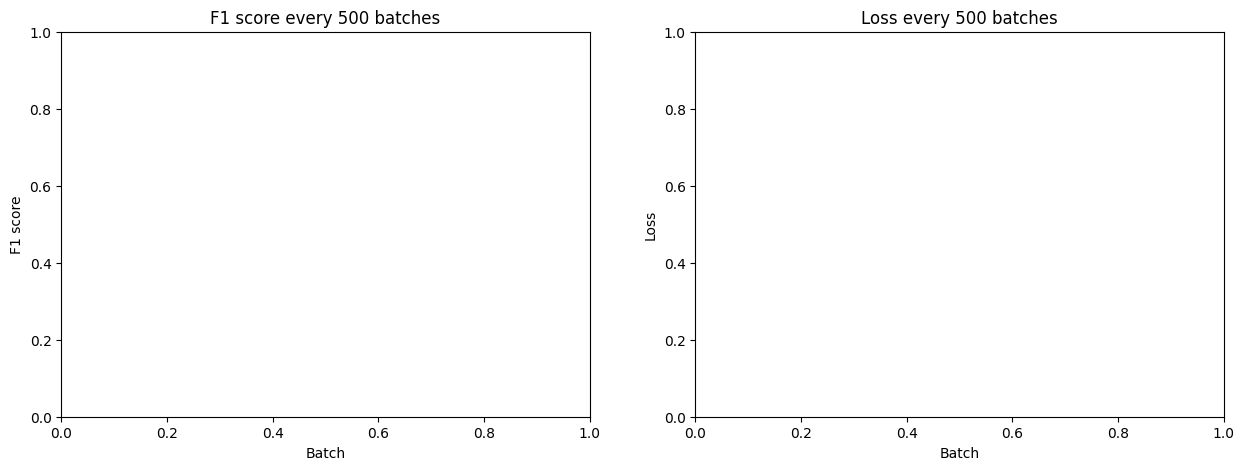

In [30]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.set_title('F1 score every 500 batches')
ax1.set_xlabel('Batch')
ax1.set_ylabel('F1 score')

ax2.set_title('Loss every 500 batches')
ax2.set_xlabel('Batch')
ax2.set_ylabel('Loss')

running_loss = 0
running_f1 = 0

loss_values = []
f1_scores = []

CHARTS PREPARATION ^ 

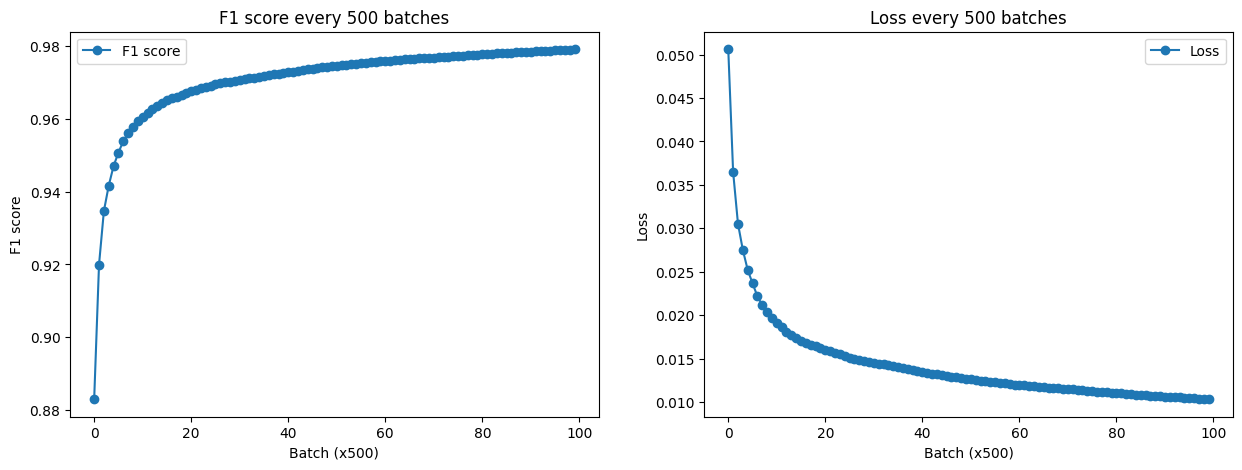

Training Loss: 0.0103 F1 score: 0.9792: 100%|██████████| 50000/50000 [6:21:37<00:00,  2.18it/s]


In [31]:
train_generator = batch_generator(train_tokens, train_labels, BATCH_SIZE, SEQ_LEN)

t = trange(50000, desc="Training", mininterval=0.5)

for i in t:
    capitalization_model.train()
    optimizer.zero_grad()

    inputs, masks, labels = next(train_generator)

    inputs = inputs.to(device)
    masks = masks.to(device)
    labels = labels.to(device)

    output = capitalization_model(inputs, masks)
    output = output.permute(0, 2, 1)

    loss = criterion(output, labels)
    loss.backward()
    optimizer.step()

    running_loss += loss.item()

    preds = torch.argmax(output.detach().cpu(), dim=1).view(-1)
    gold = labels.detach().cpu().view(-1)

    f1 = f1_score(gold, preds, average=None, zero_division=0)

    if len(f1) > 1:
        running_f1 += f1[1]
        current_f1 = f1[1]
    else:
        current_f1 = 0.0

    t.set_description(
        f"Training Loss: {(running_loss/(i+1)):.4f} F1 score: {(running_f1/(i+1)):.4f}",
        refresh=True
    )
    t.refresh()

    if (i + 1) % 500 == 0:
        f1_scores.append(running_f1 / (i + 1))
        loss_values.append(running_loss / (i + 1))

        ax1.clear()
        ax2.clear()

        ax1.set_title('F1 score every 500 batches')
        ax1.set_xlabel('Batch (x500)')
        ax1.set_ylabel('F1 score')

        ax2.set_title('Loss every 500 batches')
        ax2.set_xlabel('Batch (x500)')
        ax2.set_ylabel('Loss')

        ax1.plot(f1_scores, '-o', label='F1 score')
        ax1.legend()

        ax2.plot(loss_values, '-o', label='Loss')
        ax2.legend()

        clear_output(wait=True)
        display(fig)

MAIN TRAINING LOOP ^ 

In [32]:
def capitalize(text, model, tokenizer) -> str:
    model.eval()

    words = text.split(" ")
    text_output_words = words[:]

    all_token_ids = []
    token_word_map = []

    for word_idx, word in enumerate(words):
        word_tokens = tokenizer.tokenize(word, add_special_tokens=False)
        word_ids = tokenizer.convert_tokens_to_ids(word_tokens)

        if len(word_ids) == 0:
            continue

        all_token_ids.extend(word_ids)
        token_word_map.extend([word_idx] * len(word_ids))

    if len(all_token_ids) == 0:
        return text

    inputs = torch.tensor([all_token_ids], dtype=torch.long).to(device)
    masks = torch.ones_like(inputs).to(device)

    with torch.no_grad():
        output = model(inputs, masks)
        preds = torch.argmax(output, dim=2).squeeze(0).cpu().tolist()

    seen_words = set()

    for pred, word_idx in zip(preds, token_word_map):
        if word_idx in seen_words:
            continue
        seen_words.add(word_idx)

        word = text_output_words[word_idx]
        if len(word) == 0:
            continue

        if pred == 1:
            text_output_words[word_idx] = word[0].upper() + word[1:]
        else:
            text_output_words[word_idx] = word[0].lower() + word[1:]

    text_output = " ".join(text_output_words)
    return text_output

CAPITALIZE FUNCTION ^

In [37]:
input_text = "víteje v liberci, kterým vás provede pan kovář."
print(capitalize(input_text, capitalization_model, tokenizer))

Víteje v Liberci, kterým vás provede pan Kovář.


INPUT TEXT ^ 

In [35]:
torch.save(capitalization_model.state_dict(), "capitalization_model.pt")

SAVING THE MODEL ^ 

In [36]:
capitalization_model = CapitalizationModel("Seznam/small-e-czech")
capitalization_model.load_state_dict(torch.load("capitalization_model.pt", map_location=device))
capitalization_model.to(device)
capitalization_model.eval()

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 52657.02it/s]
ElectraModel LOAD REPORT from: Seznam/small-e-czech
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
discriminator_predictions.dense_prediction.bias   | UNEXPECTED |  | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED |  | 
discriminator_predictions.dense.weight            | UNEXPECTED |  | 
discriminator_predictions.dense.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CapitalizationModel(
  (electra_model): ElectraModel(
    (embeddings): ElectraEmbeddings(
      (word_embeddings): Embedding(30522, 128, padding_idx=0)
      (position_embeddings): Embedding(512, 128)
      (token_type_embeddings): Embedding(2, 128)
      (LayerNorm): LayerNorm((128,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (embeddings_project): Linear(in_features=128, out_features=256, bias=True)
    (encoder): ElectraEncoder(
      (layer): ModuleList(
        (0-11): 12 x ElectraLayer(
          (attention): ElectraAttention(
            (self): ElectraSelfAttention(
              (query): Linear(in_features=256, out_features=256, bias=True)
              (key): Linear(in_features=256, out_features=256, bias=True)
              (value): Linear(in_features=256, out_features=256, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): ElectraSelfOutput(
              (dense): Linear(in

ENABLING THE SAVED MODEL ^ 